In [4]:
%pip install tensorflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 223.5/223.5 MB 4.5 MB/s  0:00:37m0:00:0100:02
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 28.6 MB/s  0:00:00m0:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 26.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 676.9/676.9 kB 14.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 27.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.8/25.8 MB 35.0 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 818.2/818.2 kB 28.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22/22 [tensorflow]2 [tensorflow]

[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


# Task 2 — Season Classification

This notebook develops an image classification model to predict the season associated with each fashion item: **Fall, Spring, Summer, or Winter**.

The modelling pipeline uses the cleaned metadata produced by the shared EDA notebook. Particular attention is given to class imbalance and data leakage caused by repeated product records.

In [5]:
# ============================================
# CELL 1 - Setup and project paths
# ============================================

from pathlib import Path
import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf

from sklearn.model_selection import StratifiedGroupKFold
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    balanced_accuracy_score,
    classification_report,
    ConfusionMatrixDisplay
)

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

# --------------------------------------------
# Detect repository root
# Works whether notebook is launched from
# project root or /notebooks
# --------------------------------------------

CURRENT_DIR = Path.cwd()

if (CURRENT_DIR / "A2_FashionDataset").exists():
    PROJECT_DIR = CURRENT_DIR

elif (CURRENT_DIR.parent / "A2_FashionDataset").exists():
    PROJECT_DIR = CURRENT_DIR.parent

else:
    raise FileNotFoundError(
        "Cannot find A2_FashionDataset."
    )

DATA_ROOT = PROJECT_DIR / "A2_FashionDataset"

DATASET_DIR = DATA_ROOT / "FashionDataset"
PROCESSED_DIR = DATA_ROOT / "processed"

TRAIN_IMAGE_DIR = (
    DATASET_DIR / "train" / "images_train"
)

TEST_IMAGE_DIR = (
    DATASET_DIR / "test" / "images_test"
)

CLEAN_TRAIN_CSV = (
    PROCESSED_DIR / "clean_train_metadata.csv"
)

PREDICTION_CSV = (
    PROCESSED_DIR / "prediction_metadata.csv"
)

OUTPUT_DIR = PROJECT_DIR / "outputs"
ARTIFACT_DIR = PROJECT_DIR / "artifacts"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

print("Project directory :", PROJECT_DIR)
print("Processed data    :", PROCESSED_DIR)
print("TensorFlow        :", tf.__version__)
print("GPU(s)            :", tf.config.list_physical_devices("GPU"))

Project directory : /Users/_thu_thuu/Desktop/RMIT/2026sem2/machine learning/Fashion-Intelligence-System-1
Processed data    : /Users/_thu_thuu/Desktop/RMIT/2026sem2/machine learning/Fashion-Intelligence-System-1/A2_FashionDataset/processed
TensorFlow        : 2.21.0
GPU(s)            : []


In [6]:
# ============================================
# CELL 2 - Load processed metadata
# ============================================

train = pd.read_csv(CLEAN_TRAIN_CSV)
prediction = pd.read_csv(PREDICTION_CSV)

print("Clean training rows :", len(train))
print("Unseen test rows     :", len(prediction))

print("\nTraining columns:")
print(train.columns.tolist())

print("\nPrediction columns:")
print(prediction.columns.tolist())

assert len(train) == 38612
assert len(prediction) == 5829

Clean training rows : 38612
Unseen test rows     : 5829

Training columns:
['id', 'gender', 'masterCategory', 'subCategory', 'articleType', 'baseColour', 'season', 'year', 'usage', 'productDisplayName', 'image_path']

Prediction columns:
['id', 'gender', 'articleType', 'season', 'usage', 'image_path']


In [7]:
# ============================================
# CELL 3 - Rebuild portable image paths
# ============================================

train["image_path"] = train["id"].apply(
    lambda image_id:
    str(TRAIN_IMAGE_DIR / f"{image_id}.jpg")
)

prediction["image_path"] = prediction["id"].apply(
    lambda image_id:
    str(TEST_IMAGE_DIR / f"{image_id}.jpg")
)

train_path_valid = train["image_path"].apply(
    lambda p: Path(p).exists()
)

test_path_valid = prediction["image_path"].apply(
    lambda p: Path(p).exists()
)

print(
    "Valid training image paths:",
    train_path_valid.sum(),
    "/",
    len(train)
)

print(
    "Valid unseen image paths:",
    test_path_valid.sum(),
    "/",
    len(prediction)
)

assert train_path_valid.all()
assert test_path_valid.all()

Valid training image paths: 38612 / 38612
Valid unseen image paths: 5829 / 5829


## 1. Task-specific Data Preparation

Only observations with a valid `season` label are retained for this task. Missing values in unrelated variables are not removed because they are not required for image-based season classification.

Image paths are rebuilt locally from each product ID to ensure that the notebook remains portable across different group members' computers.

In [8]:
# ============================================
# CELL 4 - Create Season task dataset
# ============================================

season_df = (
    train
    .dropna(subset=["season"])
    .copy()
    .reset_index(drop=True)
)

print("Rows before Season filtering :", len(train))
print("Missing Season labels        :", train["season"].isna().sum())
print("Usable Season observations   :", len(season_df))

print("\nSeason classes:")
print(sorted(season_df["season"].unique()))

assert season_df["season"].isna().sum() == 0
assert season_df["season"].nunique() == 4

Rows before Season filtering : 38612
Missing Season labels        : 20
Usable Season observations   : 38592

Season classes:
['Fall', 'Spring', 'Summer', 'Winter']


,Count,Percentage
season,,
Summer,19135,49.58
Fall,10512,27.24
Winter,7379,19.12
Spring,1566,4.06


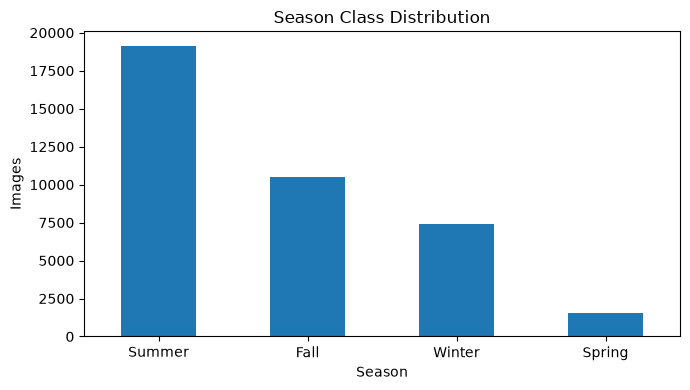

In [9]:
# ============================================
# CELL 5 - Season class distribution
# ============================================

season_counts = (
    season_df["season"]
    .value_counts()
)

season_percent = (
    season_df["season"]
    .value_counts(normalize=True)
    .mul(100)
)

season_summary = pd.DataFrame({
    "Count": season_counts,
    "Percentage": season_percent.round(2)
})

display(season_summary)

ax = season_counts.plot(
    kind="bar",
    figsize=(7, 4)
)

ax.set_title("Season Class Distribution")
ax.set_xlabel("Season")
ax.set_ylabel("Images")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 2. Leakage-safe Train, Validation and Test Split

The EDA identified repeated product names and duplicate product records. A conventional random stratified split would therefore allow visually identical or highly similar products to appear in both training and validation data.

To reduce this leakage risk, `StratifiedGroupKFold` is used with `productDisplayName` as the grouping variable while preserving the season class distribution as closely as possible.

In [10]:
# ============================================
# CELL 6 - Encode Season labels and groups
# ============================================

CLASS_NAMES = [
    "Fall",
    "Spring",
    "Summer",
    "Winter"
]

class_to_index = {
    class_name: index
    for index, class_name
    in enumerate(CLASS_NAMES)
}

index_to_class = {
    index: class_name
    for class_name, index
    in class_to_index.items()
}

season_df["label"] = (
    season_df["season"]
    .map(class_to_index)
    .astype("int32")
)

# Same product name must stay in same partition.
# Missing product names use unique image id instead.
season_df["split_group"] = (
    season_df["productDisplayName"]
    .fillna(
        "__ID_" +
        season_df["id"].astype(str)
    )
)

print("Class mapping:")
print(class_to_index)

print(
    "\nUnique split groups:",
    season_df["split_group"].nunique()
)


Class mapping:
{'Fall': 0, 'Spring': 1, 'Summer': 2, 'Winter': 3}

Unique split groups: 27533


In [11]:
# ============================================
# CELL 7 - Leakage-safe grouped split
# ============================================

# --------------------------------------------
# Step 1:
# Separate ~1/7 as untouched internal test
# --------------------------------------------

outer_splitter = StratifiedGroupKFold(
    n_splits=7,
    shuffle=True,
    random_state=SEED
)

trainval_idx, test_idx = next(
    outer_splitter.split(
        season_df,
        y=season_df["label"],
        groups=season_df["split_group"]
    )
)

trainval_df = (
    season_df.iloc[trainval_idx]
    .copy()
    .reset_index(drop=True)
)

test_df = (
    season_df.iloc[test_idx]
    .copy()
    .reset_index(drop=True)
)

# --------------------------------------------
# Step 2:
# Separate ~1/6 of remaining data as validation
# --------------------------------------------

inner_splitter = StratifiedGroupKFold(
    n_splits=6,
    shuffle=True,
    random_state=SEED
)

train_idx, val_idx = next(
    inner_splitter.split(
        trainval_df,
        y=trainval_df["label"],
        groups=trainval_df["split_group"]
    )
)

train_df = (
    trainval_df.iloc[train_idx]
    .copy()
    .reset_index(drop=True)
)

val_df = (
    trainval_df.iloc[val_idx]
    .copy()
    .reset_index(drop=True)
)

print("Train      :", len(train_df))
print("Validation :", len(val_df))
print("Test       :", len(test_df))

print(
    "\nPercentage:",
    {
        "train": round(len(train_df) / len(season_df) * 100, 2),
        "validation": round(len(val_df) / len(season_df) * 100, 2),
        "test": round(len(test_df) / len(season_df) * 100, 2)
    }
)

Train      : 27565
Validation : 5513
Test       : 5514

Percentage: {'train': 71.43, 'validation': 14.29, 'test': 14.29}


In [12]:
# ============================================
# CELL 8 - Verify split integrity
# ============================================

train_groups = set(train_df["split_group"])
val_groups = set(val_df["split_group"])
test_groups = set(test_df["split_group"])

train_val_overlap = train_groups & val_groups
train_test_overlap = train_groups & test_groups
val_test_overlap = val_groups & test_groups

print(
    "Train / Validation group overlap:",
    len(train_val_overlap)
)

print(
    "Train / Test group overlap:",
    len(train_test_overlap)
)

print(
    "Validation / Test group overlap:",
    len(val_test_overlap)
)

assert len(train_val_overlap) == 0
assert len(train_test_overlap) == 0
assert len(val_test_overlap) == 0

print("\nLeakage check PASSED.")

Train / Validation group overlap: 0
Train / Test group overlap: 0
Validation / Test group overlap: 0

Leakage check PASSED.


In [14]:
# ============================================
# CELL 9 - Verify class distributions
# ============================================

def distribution(df):
    return (
        df["season"]
        .value_counts(normalize=True)
        .reindex(CLASS_NAMES)
        .mul(100)
        .round(2)
    )


split_distribution = pd.DataFrame({
    "Train %": distribution(train_df),
    "Validation %": distribution(val_df),
    "Test %": distribution(test_df)
})

display(split_distribution)

,Train %,Validation %,Test %
season,,,
Fall,27.24,27.24,27.24
Spring,4.06,4.06,4.04
Summer,49.58,49.57,49.58
Winter,19.12,19.12,19.13


## 3. Class Imbalance Handling

The season target is imbalanced, with Summer representing approximately half of the labelled observations while Spring is substantially under-represented.

Class weights are therefore calculated from the training partition so that errors on minority classes receive greater importance during model optimisation. Evaluation will use Macro-F1 and Balanced Accuracy in addition to overall Accuracy.

In [15]:
# ============================================
# CELL 10 - Compute class weights
# ============================================

classes = np.arange(len(CLASS_NAMES))

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=train_df["label"].values
)

CLASS_WEIGHTS = {
    int(class_index): float(weight)
    for class_index, weight
    in zip(classes, weights)
}

print("Class weights:")

for class_index, weight in CLASS_WEIGHTS.items():
    print(
        f"{index_to_class[class_index]:7s}: "
        f"{weight:.4f}"
    )

Class weights:
Fall   : 0.9179
Spring : 6.1584
Summer : 0.5042
Winter : 1.3076


## 4. Image Preprocessing

The image preprocessing procedure follows the shared EDA contract:

- convert images to RGB;
- resize images to 60 × 80 pixels;
- convert pixel values to `float32`;
- scale pixel values from `[0, 255]` to `[0, 1]`.

The same preprocessing procedure is applied consistently to training, validation, internal test and unseen prediction images.

In [16]:
# ============================================
# CELL 11 - Image preprocessing pipeline
# ============================================

IMG_HEIGHT = 80
IMG_WIDTH = 60
CHANNELS = 3

BATCH_SIZE = 64

AUTOTUNE = tf.data.AUTOTUNE


def load_image_tf(image_path, label):

    image = tf.io.read_file(image_path)

    image = tf.io.decode_jpeg(
        image,
        channels=CHANNELS
    )

    # Explicit resize handles off-spec images
    image = tf.image.resize(
        image,
        [IMG_HEIGHT, IMG_WIDTH]
    )

    image = tf.cast(
        image,
        tf.float32
    )

    image = image / 255.0

    return image, label


def make_dataset(
    dataframe,
    training=False
):

    paths = (
        dataframe["image_path"]
        .astype(str)
        .values
    )

    labels = (
        dataframe["label"]
        .astype(np.int32)
        .values
    )

    dataset = (
        tf.data.Dataset
        .from_tensor_slices(
            (paths, labels)
        )
    )

    if training:

        dataset = dataset.shuffle(
            buffer_size=min(
                len(dataframe),
                10000
            ),
            seed=SEED,
            reshuffle_each_iteration=True
        )

    dataset = dataset.map(
        load_image_tf,
        num_parallel_calls=AUTOTUNE
    )

    dataset = dataset.batch(
        BATCH_SIZE
    )

    dataset = dataset.prefetch(
        AUTOTUNE
    )

    return dataset


train_ds = make_dataset(
    train_df,
    training=True
)

val_ds = make_dataset(
    val_df
)

test_ds = make_dataset(
    test_df
)

print("TensorFlow datasets created.")

TensorFlow datasets created.


## 5. Baseline Model

A majority-class classifier is used as a minimum performance benchmark. Since Summer is the dominant class, a model that simply predicts Summer for every image can achieve relatively high accuracy despite having no useful predictive capability.

The trained CNN should therefore outperform this baseline not only in Accuracy but also in Macro-F1 and Balanced Accuracy.

In [17]:
# ============================================
# CELL 12 - Majority-class baseline
# ============================================

majority_label = (
    train_df["label"]
    .mode()
    .iloc[0]
)

baseline_predictions = np.full(
    len(test_df),
    majority_label
)

baseline_accuracy = accuracy_score(
    test_df["label"],
    baseline_predictions
)

baseline_macro_f1 = f1_score(
    test_df["label"],
    baseline_predictions,
    average="macro"
)

baseline_balanced_accuracy = (
    balanced_accuracy_score(
        test_df["label"],
        baseline_predictions
    )
)

print(
    "Majority class:",
    index_to_class[majority_label]
)

print(
    f"Accuracy          : {baseline_accuracy:.4f}"
)

print(
    f"Macro-F1          : {baseline_macro_f1:.4f}"
)

print(
    f"Balanced Accuracy : "
    f"{baseline_balanced_accuracy:.4f}"
)

Majority class: Summer
Accuracy          : 0.4958
Macro-F1          : 0.1657
Balanced Accuracy : 0.2500


## 6. CNN Model Development

A custom Convolutional Neural Network (CNN) is trained from scratch for the four-class season classification problem.

Moderate image augmentation is applied during training to improve generalisation without excessively altering the low-resolution fashion images. Class weighting, dropout, batch normalisation, early stopping and learning-rate reduction are used to improve training stability and reduce overfitting.

In [18]:
# ============================================
# CELL 13 - Data augmentation
# ============================================

data_augmentation = tf.keras.Sequential(
    [
        tf.keras.layers.RandomFlip(
            "horizontal"
        ),

        tf.keras.layers.RandomRotation(
            0.03
        ),

        tf.keras.layers.RandomZoom(
            0.08
        ),

        tf.keras.layers.RandomTranslation(
            height_factor=0.05,
            width_factor=0.05
        ),

        tf.keras.layers.RandomContrast(
            0.10
        )
    ],
    name="season_augmentation"
)

In [19]:
# ============================================
# CELL 14 - Build Season CNN from scratch
# ============================================

from tensorflow.keras import (
    layers,
    models,
    regularizers
)

NUM_CLASSES = len(CLASS_NAMES)

inputs = layers.Input(
    shape=(
        IMG_HEIGHT,
        IMG_WIDTH,
        CHANNELS
    ),
    name="image"
)

x = data_augmentation(inputs)

# --------------------------------------------
# Convolution block 1
# --------------------------------------------

x = layers.Conv2D(
    32,
    kernel_size=3,
    padding="same",
    use_bias=False
)(x)

x = layers.BatchNormalization()(x)
x = layers.ReLU()(x)

x = layers.Conv2D(
    32,
    kernel_size=3,
    padding="same",
    use_bias=False
)(x)

x = layers.BatchNormalization()(x)
x = layers.ReLU()(x)

x = layers.MaxPooling2D()(x)


# --------------------------------------------
# Convolution block 2
# --------------------------------------------

x = layers.Conv2D(
    64,
    kernel_size=3,
    padding="same",
    use_bias=False
)(x)

x = layers.BatchNormalization()(x)
x = layers.ReLU()(x)

x = layers.Conv2D(
    64,
    kernel_size=3,
    padding="same",
    use_bias=False
)(x)

x = layers.BatchNormalization()(x)
x = layers.ReLU()(x)

x = layers.MaxPooling2D()(x)


# --------------------------------------------
# Convolution block 3
# --------------------------------------------

x = layers.Conv2D(
    128,
    kernel_size=3,
    padding="same",
    use_bias=False
)(x)

x = layers.BatchNormalization()(x)
x = layers.ReLU()(x)

x = layers.Conv2D(
    128,
    kernel_size=3,
    padding="same",
    use_bias=False
)(x)

x = layers.BatchNormalization()(x)
x = layers.ReLU()(x)

x = layers.MaxPooling2D()(x)


# --------------------------------------------
# Classification head
# --------------------------------------------

x = layers.GlobalAveragePooling2D()(x)

x = layers.Dense(
    128,
    activation="relu",
    kernel_regularizer=regularizers.l2(1e-4)
)(x)

x = layers.Dropout(0.40)(x)

outputs = layers.Dense(
    NUM_CLASSES,
    activation="softmax",
    name="season"
)(x)

season_model = models.Model(
    inputs=inputs,
    outputs=outputs,
    name="season_custom_cnn"
)

season_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-3
    ),

    loss=tf.keras.losses.SparseCategoricalCrossentropy(),

    metrics=[
        tf.keras.metrics.SparseCategoricalAccuracy(
            name="accuracy"
        )
    ]
)

season_model.summary()

Model: "season_custom_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image (InputLayer)              │ (None, 80, 60, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ season_augmentation             │ (None, 80, 60, 3)      │             0 │
│ (Sequential)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 80, 60, 32)     │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 80, 60, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 80, 60, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 80, 60, 32)     │         9,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 80, 60, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 80, 60, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 40, 30, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 40, 30, 64)     │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 40, 30, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 40, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 40, 30, 64)     │        36,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 40, 30, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_3 (ReLU)                  │ (None, 40, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 20, 15, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 20, 15, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 20, 15, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_4 (ReLU)                  │ (None, 20, 15, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 20, 15, 128)    │       147,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 20, 15, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 305,380 (1.16 MB)

 Trainable params: 304,484 (1.16 MB)

 Non-trainable params: 896 (3.50 KB)

In [20]:
# ============================================
# CELL 15 - Training callbacks
# ============================================

MODEL_PATH = (
    ARTIFACT_DIR /
    "task2_season_best.keras"
)

callbacks = [

    tf.keras.callbacks.ModelCheckpoint(
        MODEL_PATH,
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    ),

    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1
    )
]


In [21]:
# ============================================
# CELL 16 - Train Season classifier
# ============================================

EPOCHS = 30

history = season_model.fit(
    train_ds,

    validation_data=val_ds,

    epochs=EPOCHS,

    class_weight=CLASS_WEIGHTS,

    callbacks=callbacks,

    verbose=1
)

Epoch 1/30


/Users/_thu_thuu/Desktop/RMIT/2026sem2/machine learning/VS code/MachineLearning/.venv/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


431/431 ━━━━━━━━━━━━━━━━━━━━ 0s 565ms/step - accuracy: 0.4536 - loss: 1.1546
Epoch 1: val_loss improved from None to 1.19968, saving model to /Users/_thu_thuu/Desktop/RMIT/2026sem2/machine learning/Fashion-Intelligence-System-1/artifacts/task2_season_best.keras

Epoch 1: finished saving model to /Users/_thu_thuu/Desktop/RMIT/2026sem2/machine learning/Fashion-Intelligence-System-1/artifacts/task2_season_best.keras
431/431 ━━━━━━━━━━━━━━━━━━━━ 256s 587ms/step - accuracy: 0.4536 - loss: 1.1546 - val_accuracy: 0.4714 - val_loss: 1.1997 - learning_rate: 0.0010
Epoch 2/30
431/431 ━━━━━━━━━━━━━━━━━━━━ 0s 529ms/step - accuracy: 0.5322 - loss: 0.9914
Epoch 2: val_loss did not improve from 1.19968
431/431 ━━━━━━━━━━━━━━━━━━━━ 237s 549ms/step - accuracy: 0.5322 - loss: 0.9914 - val_accuracy: 0.4513 - val_loss: 1.3515 - learning_rate: 0.0010
Epoch 3/30
431/431 ━━━━━━━━━━━━━━━━━━━━ 0s 512ms/step - accuracy: 0.5715 - loss: 0.9330
Epoch 3: val_loss improved from 1.19968 to 1.09139, saving model to /U

In [22]:
# ============================================
# CELL 17 - Training history
# ============================================

history_df = pd.DataFrame(
    history.history
)

display(history_df.tail())

plt.figure(figsize=(8, 5))

plt.plot(
    history_df["accuracy"],
    label="Training"
)

plt.plot(
    history_df["val_accuracy"],
    label="Validation"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Season Classification Accuracy")
plt.legend()

plt.tight_layout()
plt.show()


plt.figure(figsize=(8, 5))

plt.plot(
    history_df["loss"],
    label="Training"
)

plt.plot(
    history_df["val_loss"],
    label="Validation"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Season Classification Loss")
plt.legend()

plt.tight_layout()
plt.show()

,accuracy,loss,val_accuracy,val_loss,learning_rate
25,0.650789,0.753924,0.668239,0.804023,0.000016
26,0.651116,0.752892,0.675676,0.796972,0.000016
27,0.652168,0.756464,0.669146,0.803216,0.000008
28,0.651442,0.752938,0.671504,0.800966,0.000008
29,0.656775,0.751960,0.667876,0.805582,0.000004


KeyboardInterrupt: 

## 7. Model Evaluation

Model performance is evaluated using:

- Accuracy;
- Macro-F1;
- Weighted-F1;
- Balanced Accuracy;
- per-class precision, recall and F1-score;
- normalised confusion matrix.

Macro-F1 and Balanced Accuracy are particularly important because of the unequal class distribution.

In [ ]:
# ============================================
# CELL 18 - Validation evaluation
# ============================================

val_probabilities = season_model.predict(
    val_ds,
    verbose=1
)

val_predictions = np.argmax(
    val_probabilities,
    axis=1
)

y_val = val_df["label"].values

val_accuracy = accuracy_score(
    y_val,
    val_predictions
)

val_macro_f1 = f1_score(
    y_val,
    val_predictions,
    average="macro"
)

val_weighted_f1 = f1_score(
    y_val,
    val_predictions,
    average="weighted"
)

val_balanced_accuracy = (
    balanced_accuracy_score(
        y_val,
        val_predictions
    )
)

print("=" * 50)
print("VALIDATION RESULTS")
print("=" * 50)

print(
    f"Accuracy          : {val_accuracy:.4f}"
)

print(
    f"Macro-F1          : {val_macro_f1:.4f}"
)

print(
    f"Weighted-F1       : {val_weighted_f1:.4f}"
)

print(
    f"Balanced Accuracy : {val_balanced_accuracy:.4f}"
)

print("\nClassification report:\n")

print(
    classification_report(
        y_val,
        val_predictions,
        target_names=CLASS_NAMES,
        digits=4
    )
)

In [ ]:
# ============================================
# CELL 19 - Validation confusion matrix
# ============================================

fig, ax = plt.subplots(
    figsize=(7, 6)
)

ConfusionMatrixDisplay.from_predictions(
    y_val,
    val_predictions,
    display_labels=CLASS_NAMES,
    normalize="true",
    values_format=".2f",
    ax=ax
)

ax.set_title(
    "Season Classification - Normalised Confusion Matrix"
)

plt.tight_layout()
plt.show()

In [ ]:
# ============================================
# CELL 20 - Final internal test evaluation
# ============================================

test_probabilities = season_model.predict(
    test_ds,
    verbose=1
)

test_predictions = np.argmax(
    test_probabilities,
    axis=1
)

y_test = test_df["label"].values

test_accuracy = accuracy_score(
    y_test,
    test_predictions
)

test_macro_f1 = f1_score(
    y_test,
    test_predictions,
    average="macro"
)

test_weighted_f1 = f1_score(
    y_test,
    test_predictions,
    average="weighted"
)

test_balanced_accuracy = (
    balanced_accuracy_score(
        y_test,
        test_predictions
    )
)

print("=" * 55)
print("FINAL SEASON TEST RESULTS")
print("=" * 55)

print(
    f"Accuracy          : {test_accuracy:.4f}"
)

print(
    f"Macro-F1          : {test_macro_f1:.4f}"
)

print(
    f"Weighted-F1       : {test_weighted_f1:.4f}"
)

print(
    f"Balanced Accuracy : {test_balanced_accuracy:.4f}"
)

print("\nClassification report:\n")

print(
    classification_report(
        y_test,
        test_predictions,
        target_names=CLASS_NAMES,
        digits=4
    )
)

In [ ]:
# ============================================
# CELL 21 - Baseline vs final CNN
# ============================================

comparison = pd.DataFrame({

    "Model": [
        "Majority Baseline",
        "Custom CNN"
    ],

    "Accuracy": [
        baseline_accuracy,
        test_accuracy
    ],

    "Macro-F1": [
        baseline_macro_f1,
        test_macro_f1
    ],

    "Balanced Accuracy": [
        baseline_balanced_accuracy,
        test_balanced_accuracy
    ]
})

display(
    comparison.round(4)
)

## 8. Error Analysis

Misclassified observations are inspected to identify systematic confusion between seasons and cases where the model produces incorrect predictions with high confidence.

This analysis is also useful because the EDA identified inconsistencies in season labels among repeated product records, suggesting that some classification errors may reflect label ambiguity rather than purely model failure.

In [ ]:
# ============================================
# CELL 22 - Error analysis
# ============================================

error_df = test_df.copy()

error_df["PredictedLabel"] = (
    test_predictions
)

error_df["PredictedSeason"] = (
    error_df["PredictedLabel"]
    .map(index_to_class)
)

error_df["Confidence"] = (
    test_probabilities.max(axis=1)
)

errors = error_df[
    error_df["label"]
    != error_df["PredictedLabel"]
].copy()

print(
    "Incorrect predictions:",
    len(errors),
    "/",
    len(test_df)
)

display(
    errors[
        [
            "id",
            "articleType",
            "season",
            "PredictedSeason",
            "Confidence"
        ]
    ]
    .sort_values(
        "Confidence",
        ascending=False
    )
    .head(15)
)

In [ ]:
# ============================================
# CELL 23 - Visualise prediction errors
# ============================================

sample_errors = (
    errors
    .sort_values(
        "Confidence",
        ascending=False
    )
    .head(9)
)

fig, axes = plt.subplots(
    3,
    3,
    figsize=(10, 13),
    dpi=130
)

for ax, (_, row) in zip(
    axes.flatten(),
    sample_errors.iterrows()
):

    image = plt.imread(
        row["image_path"]
    )

    ax.imshow(
        image,
        interpolation="nearest"
    )

    ax.set_title(
        f"{row['articleType']}\n"
        f"True: {row['season']}\n"
        f"Pred: {row['PredictedSeason']} "
        f"({row['Confidence']:.2f})",
        fontsize=9
    )

    ax.axis("off")

plt.tight_layout()
plt.show()

## 9. Unseen Test Prediction and Export

After final evaluation, the trained model is applied to the 5,829 unseen test images. Predicted season labels are inserted into the original prediction structure without changing the number or order of observations.

The trained model, class mapping, evaluation metrics and Task 2 prediction file are then exported for integration with the other assignment tasks.

In [ ]:
# ============================================
# CELL 24 - Unseen test image pipeline
# ============================================

def load_unseen_image(image_path):

    image = tf.io.read_file(image_path)

    image = tf.io.decode_jpeg(
        image,
        channels=CHANNELS
    )

    image = tf.image.resize(
        image,
        [IMG_HEIGHT, IMG_WIDTH]
    )

    image = tf.cast(
        image,
        tf.float32
    ) / 255.0

    return image


unseen_paths = (
    prediction["image_path"]
    .astype(str)
    .values
)

unseen_ds = (
    tf.data.Dataset
    .from_tensor_slices(
        unseen_paths
    )
)

unseen_ds = unseen_ds.map(
    load_unseen_image,
    num_parallel_calls=AUTOTUNE
)

unseen_ds = unseen_ds.batch(
    BATCH_SIZE
)

unseen_ds = unseen_ds.prefetch(
    AUTOTUNE
)

print(
    "Unseen images:",
    len(unseen_paths)
)

In [ ]:
# ============================================
# CELL 25 - Predict unseen images
# ============================================

unseen_probabilities = (
    season_model.predict(
        unseen_ds,
        verbose=1
    )
)

unseen_labels = np.argmax(
    unseen_probabilities,
    axis=1
)

unseen_seasons = [
    index_to_class[int(label)]
    for label in unseen_labels
]

print(
    "Predictions generated:",
    len(unseen_seasons)
)

print(
    "First 10:",
    unseen_seasons[:10]
)

assert len(unseen_seasons) == 5829

In [ ]:
# ============================================
# CELL 26 - Save Season predictions
# ============================================

season_output = prediction[
    [
        "id",
        "gender",
        "articleType",
        "season",
        "usage"
    ]
].copy()

season_output["season"] = (
    unseen_seasons
)

OUTPUT_PATH = (
    OUTPUT_DIR /
    "task2_season_predictions.csv"
)

season_output.to_csv(
    OUTPUT_PATH,
    index=False
)

print("Saved:", OUTPUT_PATH)
print("Shape:", season_output.shape)

display(
    season_output.head(10)
)

assert season_output.shape == (5829, 5)
assert season_output["season"].isna().sum() == 0

In [ ]:
# ============================================
# CELL 27 - Save model metadata and metrics
# ============================================

mapping_path = (
    ARTIFACT_DIR /
    "task2_season_classes.json"
)

with open(
    mapping_path,
    "w"
) as file:

    json.dump(
        class_to_index,
        file,
        indent=4
    )


metrics = {

    "task":
        "season_classification",

    "model":
        "custom_cnn_from_scratch",

    "split":
        "stratified_group_split",

    "group_variable":
        "productDisplayName",

    "accuracy":
        float(test_accuracy),

    "macro_f1":
        float(test_macro_f1),

    "weighted_f1":
        float(test_weighted_f1),

    "balanced_accuracy":
        float(test_balanced_accuracy),

    "train_samples":
        int(len(train_df)),

    "validation_samples":
        int(len(val_df)),

    "test_samples":
        int(len(test_df)),

    "classes":
        CLASS_NAMES
}

metrics_path = (
    ARTIFACT_DIR /
    "task2_season_metrics.json"
)

with open(
    metrics_path,
    "w"
) as file:

    json.dump(
        metrics,
        file,
        indent=4
    )

print("Model   :", MODEL_PATH)
print("Classes :", mapping_path)
print("Metrics :", metrics_path)